## Early Stopping Regularization

✅ The Colab implements:

- Trains a CNN on MNIST

- Compares training with and without EarlyStopping

- Uses a 3-epoch patience strategy

- Plots validation loss to show overfitting prevention

## Setup & Imports

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
import matplotlib.pyplot as plt

## Load dataset

In [2]:
# Load dataset (MNIST)
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0
x_train = x_train[..., tf.newaxis]
x_test = x_test[..., tf.newaxis]

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


## CNN Model

In [3]:
# Define a simple CNN model
def create_model():
    model = keras.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', input_shape=(28, 28, 1)),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D((2,2)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    return model

## Configure EarlyStopping callback

In [4]:
# Configure EarlyStopping callback
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

## Training Model with and without EarlyStopping

In [5]:
# Train model with and without EarlyStopping
histories = {}

for use_early_stopping in [False, True]:
    print("\nTraining model with{} EarlyStopping".format("out" if not use_early_stopping else ""))
    model = create_model()
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    history = model.fit(
        x_train, y_train,
        epochs=30,
        batch_size=64,
        validation_data=(x_test, y_test),
        callbacks=[early_stop] if use_early_stopping else [],
        verbose=1
    )
    key = "With EarlyStopping" if use_early_stopping else "Without EarlyStopping"
    histories[key] = history


Training model without EarlyStopping


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8900 - loss: 0.3691 - val_accuracy: 0.9841 - val_loss: 0.0467
Epoch 2/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9861 - loss: 0.0464 - val_accuracy: 0.9843 - val_loss: 0.0447
Epoch 3/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9901 - loss: 0.0324 - val_accuracy: 0.9895 - val_loss: 0.0330
Epoch 4/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9927 - loss: 0.0242 - val_accuracy: 0.9869 - val_loss: 0.0400
Epoch 5/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9944 - loss: 0.0174 - val_accuracy: 0.9910 - val_loss: 0.0315
Epoch 6/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9954 - loss: 0.0137 - val_accuracy: 0.9900 - val_loss: 0.0320
Epoch 7/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9973 - loss: 0.0086 - val_accuracy: 0.9921 - val_loss: 0.0268
Epoch 8/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9975 - loss: 0.0077 - val_accuracy: 0

## Visualization

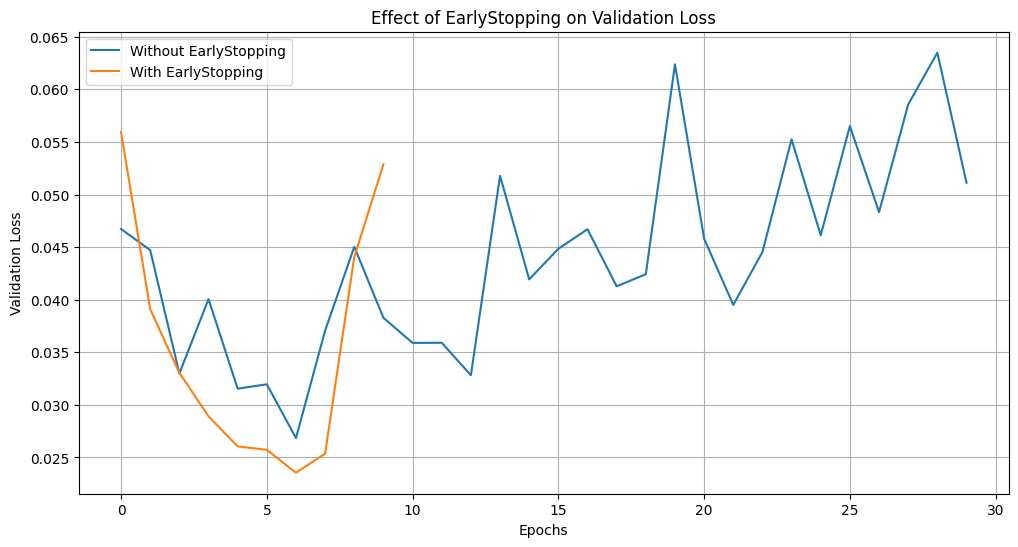

In [6]:
# Plot validation loss
plt.figure(figsize=(12, 6))
for label, history in histories.items():
    plt.plot(history.history['val_loss'], label=label)
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.legend()
plt.title('Effect of EarlyStopping on Validation Loss')
plt.grid(True)
plt.show()


Early Stopping Regularization

📘 Overview

This Colab notebook demonstrates the effect of EarlyStopping regularization in training a CNN model using TensorFlow and Keras. The technique helps prevent overfitting by stopping training once the validation performance stops improving.

🧪 Objective

To illustrate how EarlyStopping can:

Avoid overfitting

Reduce training time

Automatically restore the best model

🛠️ Implementation Details

Dataset: MNIST (grayscale digit classification)

Model Architecture:

2 Conv2D layers + MaxPooling

1 Dense hidden layer

Softmax output layer

Regularization Strategy:

EarlyStopping callback from tf.keras.callbacks

Parameters:

monitor='val_loss'

patience=3

restore_best_weights=True

Training Setup:

Epochs: Up to 30

Batch Size: 64

Optimizer: Adam

Loss: Sparse Categorical Crossentropy

📈 Results

Trained two models:

Without EarlyStopping – Runs full 30 epochs even if validation loss worsens.

With EarlyStopping – Stops early (after 3 epochs of no improvement).

Validation Loss Comparison:

EarlyStopping halts training at optimal performance point.

Prevents unnecessary computation and model degradation due to overfitting.

🧠 Insights

EarlyStopping is a lightweight, easy-to-apply regularization technique.

Saves computation and often improves generalization.

Works best when combined with other techniques (dropout, L2).

Be cautious with patience setting: too low may cause premature stopping.